# Mask coverage → pick a filtering threshold

The tiling pipeline (`preprocessing/tiling.py`) already computes a **per-tile coverage score** for
each mask type and stores it in the tiled dataset's `tiles.parquet` as these columns:
`tissue_overlap`, `epithelium_overlap`, `blur_overlap`, `folding_overlap`, `residual_overlap`.
Each is in `[0, 1]` = fraction of desired (non-artifact) pixels; tiles are kept/dropped by
thresholding these.

This notebook loads those columns straight from a tiled-dataset MLflow artifact and shows their
**distribution + CDF** so you can pick sensible thresholds.

> **Note on "AUC".** A true ROC/AUC needs a per-tile keep/discard ground truth, which we don't have.
> Instead we plot the **coverage distribution** and its **CDF** — the CDF axis directly answers
> *"if I set the threshold at T, what fraction of tiles do I keep vs drop?"*, which is exactly the
> decision you want to make. An optional luminal A/B overlay lets you check the two classes behave
> similarly under a given cutoff.

No masks or OpenSlide access needed — the overlaps are read as-is from the parquet, so the numbers
are exactly what the pipeline produced.

Edit the **Config** cell (tiled-dataset URI + which overlaps to look at), then run the **Calls** cells.

In [1]:
!python -m ensurepip --upgrade
!python -m pip install "pandas" "mlflow>3" pyarrow matplotlib openslide-python tifffile

Looking in links: /tmp/tmphji5aiyo
Processing /tmp/tmphji5aiyo/pip-25.3-py3-none-any.whl
  Using cached pandas-3.0.3-cp314-cp314-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (79 kB)
  Using cached mlflow-3.14.0-py3-none-any.whl.metadata (49 kB)
  Using cached pyarrow-25.0.0-cp314-cp314-manylinux_2_28_x86_64.whl.metadata (3.0 kB)
  Using cached openslide_python-1.4.6-cp311-abi3-manylinux1_x86_64.manylinux_2_5_x86_64.whl.metadata (5.1 kB)
  Using cached tifffile-2026.7.14-py3-none-any.whl.metadata (33 kB)
  Using cached numpy-2.5.1-cp314-cp314-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (6.6 kB)
  Using cached mlflow_skinny-3.14.0-py3-none-any.whl.metadata (50 kB)
  Using cached mlflow_tracing-3.14.0-py3-none-any.whl.metadata (19 kB)
  Using cached flask_cors-6.0.5-py3-none-any.whl.metadata (5.4 kB)
  Using cached flask-3.1.3-py3-none-any.whl.metadata (3.2 kB)
  Using cached docker-7.2.0-py3-none-any.whl.metadata (3.8 kB)
  Using cached graphene-3.4.3-py2.py3-non

In [2]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import mlflow
import numpy as np
import pandas as pd
from mlflow.artifacts import download_artifacts

# Config

This is the one cell you edit. Point `TILED_DATASET_URI` at the tiling run's MLflow artifact dir
(the one containing `slides.parquet` / `tiles.parquet`), and pick which overlaps to plot.

In [3]:
MLFLOW_TRACKING_URI = "http://mlflow-s3.rationai-mlflow"
os.environ["MLFLOW_TRACKING_URI"] = MLFLOW_TRACKING_URI
mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)

# Tiled-dataset artifact dir (contains slides.parquet + tiles.parquet). Same style as the
# TILED_DATASETS entries in check_mask_coverage.ipynb. Point this at your dataset.
# TILED_DATASET_URI = "mlflow-artifacts:/3/0b32eceb1c434abf94104bb2c54b792e/artifacts/mou_3_224"
TILED_DATASET_URI = "mlflow-artifacts:/3/eda595549e1b44269049b766032f306d/artifacts/mou_3_224"

# The overlap columns to analyze (as stored in tiles.parquet). Drop any you don't care about.
OVERLAP_COLUMNS = [
    "tissue_overlap",
    "epithelium_overlap",
    "blur_overlap",
    "folding_overlap",
    "residual_overlap",
]

# Columns whose stored values are inverted relative to the convention you want
# ("fraction of DESIRED pixels", where higher = cleaner/keep). For these, the notebook plots
# `1 - overlap` everywhere (loaded once, so summary + plots stay consistent).
# NOTE: this only relabels the interpretation for viewing; it does NOT change the parquet.
#
# folding/residual were stored inverted by an upstream struct_field bug. That bug has now been
# fixed in preprocessing/tiling.py, so datasets tiled AFTER the fix are already correct: set
# INVERT_COLUMNS = [] for those. Keep the two columns listed only when viewing an OLD dataset
# tiled before the fix (like the default URI above).
INVERT_COLUMNS = ["folding_overlap", "residual_overlap"]

# Column holding the luminal type on each tile row (for the optional A/B overlay). Set to None
# to disable the per-class split. tiling.py copies `type` onto every tile.
TYPE_COLUMN = "type"

# Functions

Run every cell in this section once, then use the **Calls** section at the bottom.

In [4]:
# ---- Load tiles.parquet from a tiled-dataset MLflow artifact ----
# type_label mirrors ml/data/datasets/labels.py:_map_luminal_type  (a luminal -> 1, b luminal -> 0)
_LUMINAL_MAP = {"a luminal": 1, "b luminal": 0}


def load_tiles(uri=TILED_DATASET_URI, overlap_columns=OVERLAP_COLUMNS,
               invert_columns=INVERT_COLUMNS, type_column=TYPE_COLUMN):
    """Download the tiled dataset's tiles.parquet and return it as a DataFrame.

    Any column in `invert_columns` is replaced with `1 - value` (fixes overlaps stored with the
    opposite convention, so higher = cleaner/keep everywhere). Adds `type_label` (luminal A=1/B=0)
    if `type_column` is present. Warns about requested overlap columns missing from the parquet.
    """
    local_dir = Path(download_artifacts(uri))
    tiles = pd.read_parquet(local_dir / "tiles.parquet")
    print(f"Loaded {len(tiles):,} tiles from {local_dir / 'tiles.parquet'}")
    print(f"Columns: {tiles.columns.tolist()}")

    missing = [c for c in overlap_columns if c not in tiles.columns]
    if missing:
        print(f"WARNING: requested overlap columns not in parquet: {missing}")

    for col_name in invert_columns:
        if col_name in tiles.columns:
            tiles[col_name] = 1.0 - tiles[col_name]
            print(f"Inverted '{col_name}' -> plotting 1 - {col_name}")

    if type_column and type_column in tiles.columns:
        tiles["type_label"] = tiles[type_column].str.strip().str.lower().map(_LUMINAL_MAP)
        print(tiles[type_column].value_counts(dropna=False).to_string())
    return tiles

In [5]:
# ---- Per-column quantile table (read cutoffs straight off it) ----
def summary_table(tiles, overlap_columns=OVERLAP_COLUMNS):
    """Count + quantiles of each overlap column.

    Includes fine LOW-end quantiles (1/2/5/10%) because for right-skewed overlaps the useful
    threshold sits in the bottom tail: e.g. the 5% row tells you the cutoff that drops ~5% of tiles.
    """
    qs = [0.0, 0.01, 0.02, 0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 1.0]
    cols = [c for c in overlap_columns if c in tiles.columns]
    out = (
        tiles[cols]
        .describe(percentiles=qs)
        .drop(index=["mean", "std"], errors="ignore")
        .T
    )
    return out

In [6]:
# ---- Plot: coverage histogram + CDF, with candidate thresholds ----
_CLASS_NAMES = {1: "a luminal", 0: "b luminal"}


def auto_xlim(values, tail=0.02, pad=0.01):
    """Zoom window that frames the informative tail of a skewed distribution.

    Returns (lo, hi) spanning the `tail` quantile (e.g. 2%) up to the max, padded a little. When
    almost every tile has coverage ~1.0, this zooms in near 1.0 where the threshold decision lives.
    Falls back to the full (0, 1) range for empty/all-NaN or degenerate (all-identical) input.
    """
    values = np.asarray(pd.Series(values).dropna())
    if values.size == 0:
        return (0.0, 1.0)
    lo = float(np.quantile(values, tail))
    hi = float(values.max())
    lo = max(0.0, lo - pad)
    hi = min(1.0, hi + pad)
    if hi - lo < 1e-6:  # degenerate (all identical) -> fall back to full range
        return (0.0, 1.0)
    return (lo, hi)


def plot_overlap(tiles, column, thresholds=(0.1, 0.25, 0.5), by_class=True,
                 bins=50, xlim=(0.0, 1.0)):
    """Histogram (left) + CDF (right) of one overlap column.

    The CDF reads directly as 'fraction of tiles dropped if threshold = x'; keep-fraction is
    printed for each candidate threshold. Optional luminal A/B overlay.

    `xlim` sets the x-axis window (bins + histogram range track it), so for heavily skewed
    columns you can zoom toward 1.0. Pass `xlim=auto_xlim(tiles[column].dropna())` to auto-frame
    the tail. The keep/drop stats below always use the FULL data, regardless of the zoom window.
    """
    if column not in tiles.columns:
        print(f"Column '{column}' not in tiles.")
        return
    values_all = tiles[column].dropna()
    if values_all.empty:
        print(f"No values for '{column}' (empty or all-NaN) -- skipping.")
        return

    lo, hi = xlim
    fig, (ax_hist, ax_cdf) = plt.subplots(1, 2, figsize=(13, 4.5))

    def _plot_series(values, label):
        values = np.asarray(values)
        ax_hist.hist(values, bins=bins, range=(lo, hi), alpha=0.5, density=True, label=label)
        xs = np.sort(values)
        ys = np.arange(1, len(xs) + 1) / len(xs)  # P(overlap <= x) = fraction dropped
        ax_cdf.plot(xs, ys, label=label)

    if by_class and "type_label" in tiles.columns and tiles["type_label"].notna().any():
        for lbl, group in tiles.dropna(subset=[column]).groupby("type_label", dropna=True):
            _plot_series(group[column], _CLASS_NAMES.get(lbl, str(lbl)))
    else:
        _plot_series(values_all, "all")

    for t in thresholds:
        if lo <= t <= hi:
            ax_hist.axvline(t, color="k", ls="--", lw=0.8)
            ax_cdf.axvline(t, color="k", ls="--", lw=0.8)

    zoom_note = "" if (lo, hi) == (0.0, 1.0) else f"  [zoom {lo:.3f}–{hi:.3f}]"
    ax_hist.set(title=f"{column}: distribution{zoom_note}", xlabel="coverage", ylabel="density",
                xlim=(lo, hi))
    ax_hist.legend()
    ax_cdf.set(title=f"{column}: CDF (= fraction dropped at threshold){zoom_note}",
               xlabel="threshold", ylabel="fraction of tiles with coverage ≤ threshold",
               xlim=(lo, hi))
    ax_cdf.legend()
    fig.tight_layout()
    plt.show()

    total = len(values_all)
    print(f"{column}: {total:,} tiles")
    for t in thresholds:
        kept = int((values_all > t).sum())
        print(f"  threshold > {t:>5}: keep {kept:>9,} ({100 * kept / total:5.1f}%), "
              f"drop {total - kept:>9,} ({100 * (total - kept) / total:5.1f}%)")

# Calls

Run these to load the dataset and inspect each overlap. Adjust `thresholds=` to your candidate
cutoffs and re-run cell 3 as needed.

In [7]:
# 1. Load tiles.parquet from the tiled-dataset artifact.
tiles = load_tiles()
tiles.head()

Loaded 6,448,835 tiles from /tmp/tmpw4xxl_md/mou_3_224/tiles.parquet
Columns: ['tile_x', 'tile_y', 'slide_id', 'type', 'mammaprint_index', 'tissue_overlap', 'blur_overlap', 'folding_overlap', 'residual_overlap', 'epithelium_overlap']
Inverted 'folding_overlap' -> plotting 1 - folding_overlap
Inverted 'residual_overlap' -> plotting 1 - residual_overlap
type
a luminal    3423054
b luminal    3025781


,tile_x,tile_y,slide_id,type,mammaprint_index,tissue_overlap,blur_overlap,folding_overlap,residual_overlap,epithelium_overlap,type_label
0,672,11088,08e11e3d9663d30a3ea804171398a9875b3f97641420be...,b luminal,-0.611,0.535635,0.959443,0.0,0.0,None,0
1,784,11088,08e11e3d9663d30a3ea804171398a9875b3f97641420be...,b luminal,-0.611,0.632892,0.961376,0.0,0.0,None,0
2,896,11088,08e11e3d9663d30a3ea804171398a9875b3f97641420be...,b luminal,-0.611,0.740912,0.968072,0.0,0.0,None,0
3,1008,11088,08e11e3d9663d30a3ea804171398a9875b3f97641420be...,b luminal,-0.611,1.000000,0.966916,0.0,0.0,None,0
4,1120,11088,08e11e3d9663d30a3ea804171398a9875b3f97641420be...,b luminal,-0.611,0.990513,0.971839,0.0,0.0,None,0


In [8]:
# 2. Quantile table — read candidate thresholds straight off it.
summary_table(tiles)

,count,min,0%,1%,2%,5%,10%,25%,50%,75%,90%,100%,max
tissue_overlap,6448835.0,0.250080,0.250080,0.266741,0.283960,0.338249,0.435507,0.723693,0.961735,1.000000,1.000000,1.000000,1.000000
blur_overlap,6448835.0,0.100028,0.100028,0.472317,0.582051,0.712173,0.797373,0.890226,0.943579,0.969687,0.982820,1.000000,1.000000
folding_overlap,6448835.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.583665,0.583665
residual_overlap,6448835.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000339,0.499980,0.499980


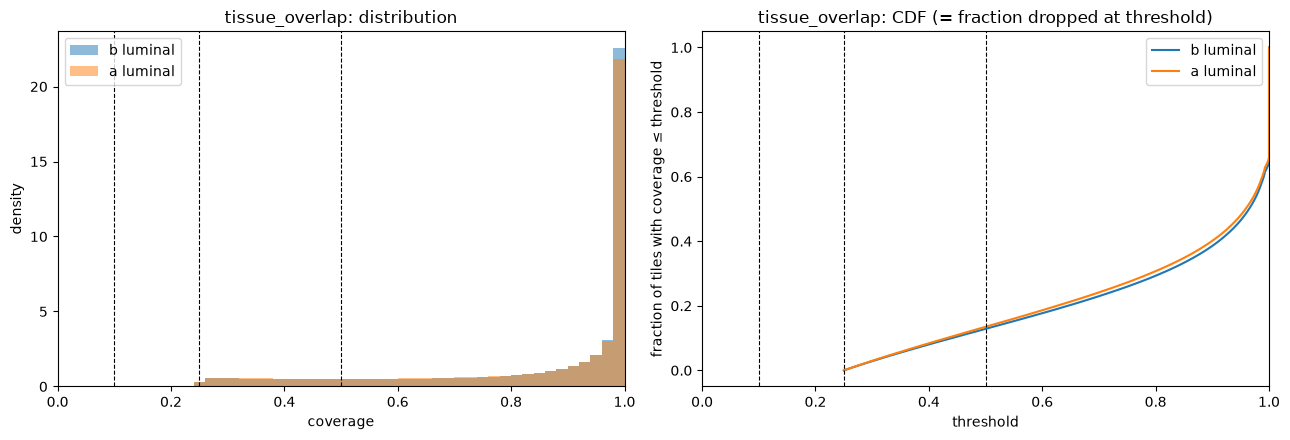

tissue_overlap: 6,448,835 tiles
  threshold >   0.1: keep 6,448,835 (100.0%), drop         0 (  0.0%)
  threshold >  0.25: keep 6,448,835 (100.0%), drop         0 (  0.0%)
  threshold >   0.5: keep 5,597,920 ( 86.8%), drop   850,915 ( 13.2%)
No values for 'epithelium_overlap' (empty or all-NaN) -- skipping.


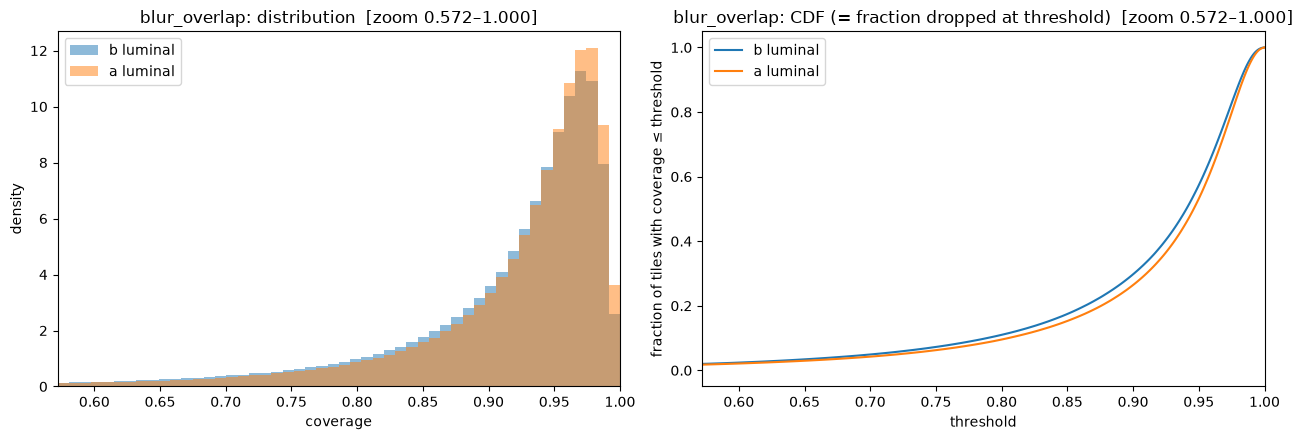

blur_overlap: 6,448,835 tiles
  threshold >   0.1: keep 6,448,835 (100.0%), drop         0 (  0.0%)
  threshold >  0.25: keep 6,435,731 ( 99.8%), drop    13,104 (  0.2%)
  threshold >   0.5: keep 6,372,239 ( 98.8%), drop    76,596 (  1.2%)


/tmp/ipykernel_112/3910932268.py:72: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.tight_layout()
/opt/venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


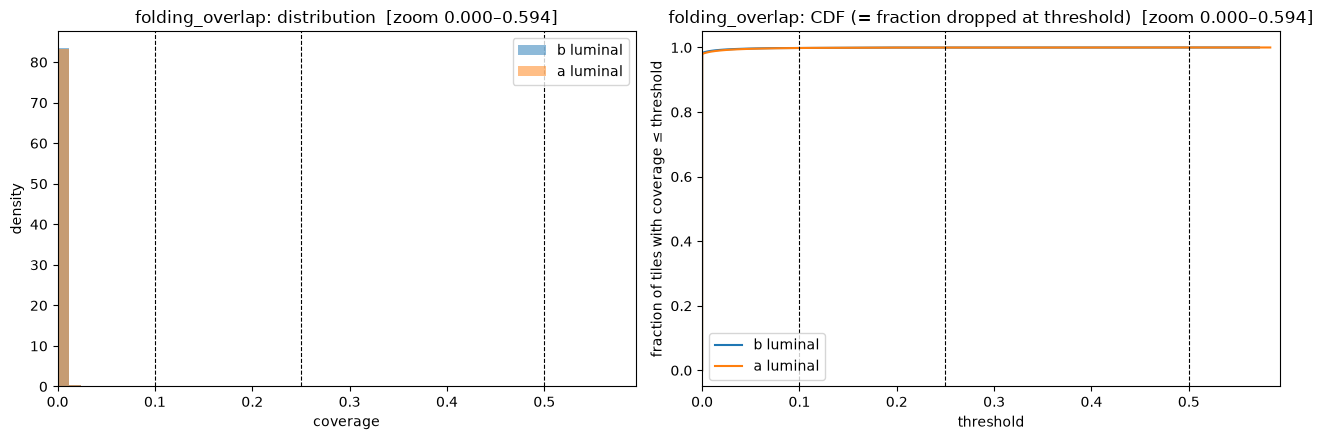

folding_overlap: 6,448,835 tiles
  threshold >   0.1: keep     9,320 (  0.1%), drop 6,439,515 ( 99.9%)
  threshold >  0.25: keep       827 (  0.0%), drop 6,448,008 (100.0%)
  threshold >   0.5: keep        20 (  0.0%), drop 6,448,815 (100.0%)


/tmp/ipykernel_112/3910932268.py:72: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.tight_layout()
/opt/venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


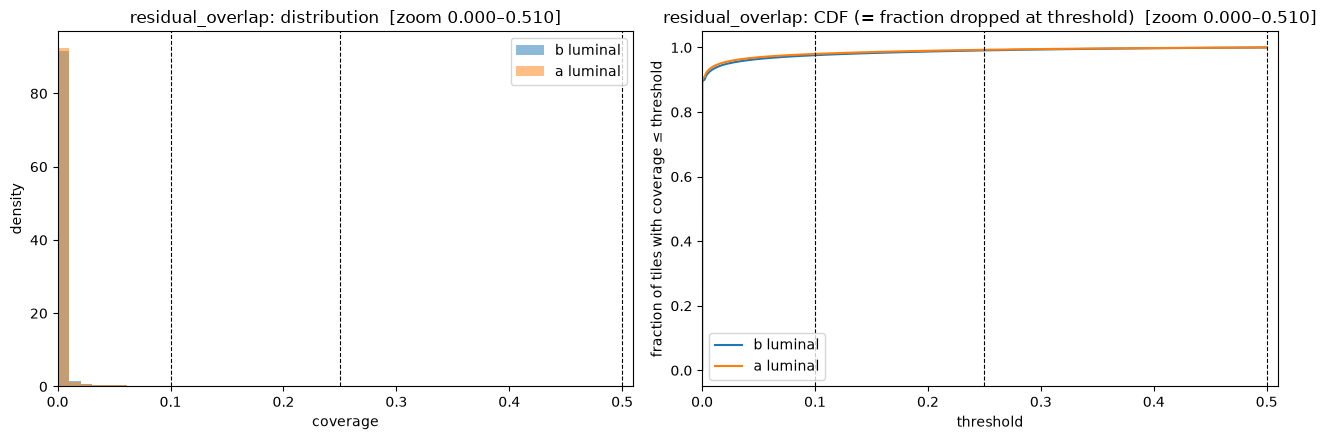

residual_overlap: 6,448,835 tiles
  threshold >   0.1: keep   140,536 (  2.2%), drop 6,308,299 ( 97.8%)
  threshold >  0.25: keep    51,756 (  0.8%), drop 6,397,079 ( 99.2%)
  threshold >   0.5: keep         0 (  0.0%), drop 6,448,835 (100.0%)


In [9]:
# 3. Distribution + CDF per overlap column.
#    - `thresholds=` : candidate cutoffs to annotate + print keep/drop for.
#    - `xlim=`       : x-axis zoom window. Only folding/residual are zoomed here (their mass sits
#                      near 1.0); the rest are shown full-range. auto_xlim frames the tail --
#                      lower `tail=` to zoom tighter, or pass a manual window like (0.9, 1.0).
ZOOM_COLUMNS = ["blur_overlap", "folding_overlap", "residual_overlap"]

for column in OVERLAP_COLUMNS:
    if column not in tiles.columns:
        continue
    if column in ZOOM_COLUMNS:
        xlim = auto_xlim(tiles[column].dropna())  # or e.g. (0.9, 1.0)
    else:
        xlim = (0.0, 1.0)
    plot_overlap(tiles, column, thresholds=(0.1, 0.25, 0.5), xlim=xlim)

## How to pick a threshold

There's no single "correct" cutoff — you're trading off **tile quality** against **how much data you keep**. Use the plots + quantile table together:

1. **Look for a gap / elbow in the distribution.** If the histogram is bimodal — a big clean lump near 1.0 and a smaller junk lump near 0 — put the threshold *in the valley between them*. That's the most defensible cutoff: it separates two populations rather than cutting into one.
2. **If there's no clear gap (just a smooth skew toward 1.0),** there's no natural boundary, so pick by **data-loss budget** instead. Decide how many tiles you're willing to drop (e.g. "≤5%") and read the cutoff off the matching low-end quantile in `summary_table` (the 5% row) or off the CDF (find where y = 0.05, take the x). A skewed column usually means the mask rarely fires, so a low cutoff (drop only the worst 1–5%) is typically enough.
3. **Match the cutoff to what the mask is *for*.**
   - `tissue_overlap` — the gate that decides a tile is on tissue at all; a moderate cutoff (e.g. 0.25–0.5) is normal. (The pipeline already drops `tissue_overlap == 0`.)
   - `epithelium_overlap` — how much tumor epithelium a tile must contain; set by how epithelium-pure you want tiles, not by data loss.
   - `blur` / `folding` / `residual` (QC) — these only remove artifacts, so keep them **lenient**: drop just the clearly-bad tail (often 0.01–0.1) so you don't throw away good tissue.
4. **Sanity-check the A/B overlay.** A QC/tissue threshold should affect luminal A and B tiles *about equally*. If one class loses far more tiles than the other at your cutoff, you're introducing class bias — loosen it or reconsider.
5. **Confirm with the printed keep/drop line.** Once a candidate looks right, add it to `thresholds=` and check the exact keep/drop counts are acceptable before committing.

In short: **cut at a gap if one exists; otherwise cut by an acceptable data-loss budget — lenient for pure-artifact masks, and balanced across A/B.**

# Raw mask pixel histograms (binary vs. continuous?)

The `*_overlap` columns above were computed upstream with an **exact-equality** rule
(`overlap = 1 - fraction(pixels == 0 or 255)`), which silently assumes the masks are binary. The
QC docs, however, say the masks are downsampled to a **continuous [0, 255]** range where `0 = clean`
and *any non-zero = artifact* — so equality may be throwing away the gray gradient.

This section is **independent of the parquet**: it opens a few raw mask files and plots their actual
pixel-value distributions. Use it to decide, per mask, whether it is effectively **binary** (mass only
at 0 and 255 → equality is fine) or **continuous** (mass spread across gray → equality under-counts
artifacts and the overlap computation needs to change).

Configure the mask sources below (QC masks are local; tissue/epithelium are MLflow), then run the
call cell. Nothing here depends on the sections above — it reads masks directly.

In [10]:
# ---- Raw mask sources (edit these) ----
from openslide import OpenSlide  # noqa: E402
from tifffile import TiffFile  # noqa: E402

PROJECT_PATH = Path("/mnt/projects/mammaprint")
DATA_MAPPING_CSV = PROJECT_PATH / "data_mapping.csv"

# QC masks are LOCAL. Searched in order; first match wins. (Same as check_mask_coverage.ipynb.)
QC_MASKS_PATHS = [
    PROJECT_PATH / "qc_masks",
    PROJECT_PATH / "qc_masks3",
    PROJECT_PATH / "qc_masks_big_diff",
]

# tissue/epithelium masks are MLflow artifact dirs; a single slide's mask is fetched per-file.
RAW_MLFLOW_MASKS = {
    "tissue": "mlflow-artifacts:/3/1d67612f123e46f6a3c6183257106512/artifacts/tissue_masks",
    "epithelium": "mlflow-artifacts:/3/0176fb9485de49699b1e16f362cff5fa/artifacts/epithelium_masks",
}

# QC filename prefixes (the slide `<name>.tiff` is appended). blur uses the PIQE MEDIAN (focus
# heatmap) file -- the continuous one per the docs -- matching what tiling.py reads.
RAW_QC_PREFIXES = {
    "blur": "Piqe_piqe_median_activity_mask_",
    "folding": "FoldingFunction_folding_test_",
    "residual": "ResidualArtifactsAndCoverage_coverage_mask_",
}

RAW_MASK_SOURCE = {  # mask_name -> "qc" | "mlflow"
    "tissue": "mlflow",
    "epithelium": "mlflow",
    "blur": "qc",
    "folding": "qc",
    "residual": "qc",
}

# Which masks to histogram, how many slides to sample, and where to cache MLflow downloads.
RAW_MASKS_TO_INSPECT = ["blur", "folding", "residual", "tissue"]
RAW_N_SLIDES = 30
RAW_MLFLOW_CACHE_DIR = Path("mlflow_masks_cache")

In [11]:
# ---- Read a raw mask's pixel values and histogram them ----
def _resolve_raw_mask_path(tiff_name, mask, mlflow_dst):
    """Path to one slide's raw mask file (fetches per-file from MLflow if needed), or None."""
    if RAW_MASK_SOURCE[mask] == "mlflow":
        file_uri = f"{RAW_MLFLOW_MASKS[mask].rstrip('/')}/{tiff_name}"
        try:
            return Path(download_artifacts(artifact_uri=file_uri, dst_path=str(mlflow_dst)))
        except Exception:
            return None
    filename = f"{RAW_QC_PREFIXES[mask]}{tiff_name}"
    for qc_path in QC_MASKS_PATHS:
        candidate = Path(qc_path) / filename
        if candidate.is_file():
            return candidate
    return None


def _read_mask_pixels(path):
    """Read one mask as a flat uint8 array at its LOWEST-resolution level (fast, full footprint).

    Masks are pyramidal BigTIFF opened via OpenSlide; the coarsest level is enough to see the
    value distribution. Returns the single (grayscale) channel flattened.
    """
    path = str(path)
    if path.lower().endswith((".ome.tiff", ".ome.tif")):
        with TiffFile(path) as tif:
            arr = tif.series[0].levels[-1].asarray()
    else:
        with OpenSlide(path) as slide:
            level = slide.level_count - 1
            size = slide.level_dimensions[level]
            arr = np.asarray(slide.read_region((0, 0), level, size).convert("L"))
    return np.asarray(arr).reshape(-1)


def inspect_raw_masks(masks=RAW_MASKS_TO_INSPECT, n_slides=RAW_N_SLIDES,
                      csv_path=DATA_MAPPING_CSV, mlflow_dst=RAW_MLFLOW_CACHE_DIR):
    """For a few slides, plot each mask's raw pixel-value histogram and print key stats.

    For each mask, prints the % of pixels at exactly 0, exactly 255, and strictly in-between
    (1..254). A large in-between fraction => CONTINUOUS mask (equality-based overlap is wrong);
    near-zero in-between => effectively BINARY.
    """
    mlflow_dst = Path(mlflow_dst)
    mlflow_dst.mkdir(parents=True, exist_ok=True)
    df = pd.read_csv(csv_path)
    df["tiff_name"] = df["path"].apply(lambda p: Path(p).with_suffix(".tiff").name)
    sample = df.head(n_slides)

    for mask in masks:
        fig, ax = plt.subplots(figsize=(9, 4))
        any_plotted = False
        for r in sample.itertuples(index=False):
            path = _resolve_raw_mask_path(r.tiff_name, mask, mlflow_dst)
            if path is None:
                print(f"{mask}: no mask file for {r.tiff_name} -- skipping")
                continue
            try:
                px = _read_mask_pixels(path)
            except Exception as e:
                print(f"{mask}: cannot read {path} ({type(e).__name__}: {e})")
                continue

            total = px.size
            frac0 = float(np.mean(px == 0))
            frac255 = float(np.mean(px == 255))
            frac_mid = float(np.mean((px > 0) & (px < 255)))
            verdict = "CONTINUOUS" if frac_mid > 0.01 else "~binary"
            print(f"{mask} [{r.tiff_name}]: ==0 {frac0:6.1%} | ==255 {frac255:6.1%} | "
                  f"1..254 {frac_mid:6.1%} -> {verdict}  (min {px.min()}, max {px.max()})")

            # Histogram of NON-zero pixels (0 dominates and would flatten the plot).
            nz = px[px > 0]
            if nz.size:
                ax.hist(nz, bins=64, range=(1, 255), alpha=0.5, label=r.tiff_name)
                any_plotted = True

        ax.set(title=f"{mask}: raw pixel values (non-zero only)", xlabel="pixel value (0..255)",
               ylabel="pixel count", xlim=(0, 255))
        if any_plotted:
            ax.legend(fontsize=8)
        fig.tight_layout()
        plt.show()
        print()

blur [P2023_0835.tiff]: ==0  35.1% | ==255  38.2% | 1..254  26.6% -> CONTINUOUS  (min 0, max 255)
blur [P2023_0836.tiff]: ==0  63.5% | ==255   0.0% | 1..254  36.5% -> CONTINUOUS  (min 0, max 255)
blur [P2023_0837.tiff]: ==0  62.8% | ==255   0.0% | 1..254  37.2% -> CONTINUOUS  (min 0, max 252)
blur [P2023_0838.tiff]: ==0  64.8% | ==255   0.0% | 1..254  35.2% -> CONTINUOUS  (min 0, max 161)
blur [P2023_0839.tiff]: ==0  60.0% | ==255   0.0% | 1..254  40.0% -> CONTINUOUS  (min 0, max 188)
blur [P2023_0840.tiff]: ==0  61.1% | ==255   0.0% | 1..254  38.9% -> CONTINUOUS  (min 0, max 250)
blur [P2023_0846.tiff]: ==0  67.8% | ==255   0.0% | 1..254  32.2% -> CONTINUOUS  (min 0, max 246)
blur [P2023_0847.tiff]: ==0  65.7% | ==255   0.0% | 1..254  34.3% -> CONTINUOUS  (min 0, max 184)
blur [P2023_0884.tiff]: ==0  51.2% | ==255  37.7% | 1..254  11.1% -> CONTINUOUS  (min 0, max 255)
blur [P2023_0939.tiff]: ==0  46.5% | ==255  33.6% | 1..254  19.9% -> CONTINUOUS  (min 0, max 255)
blur [P2023_0945.tif

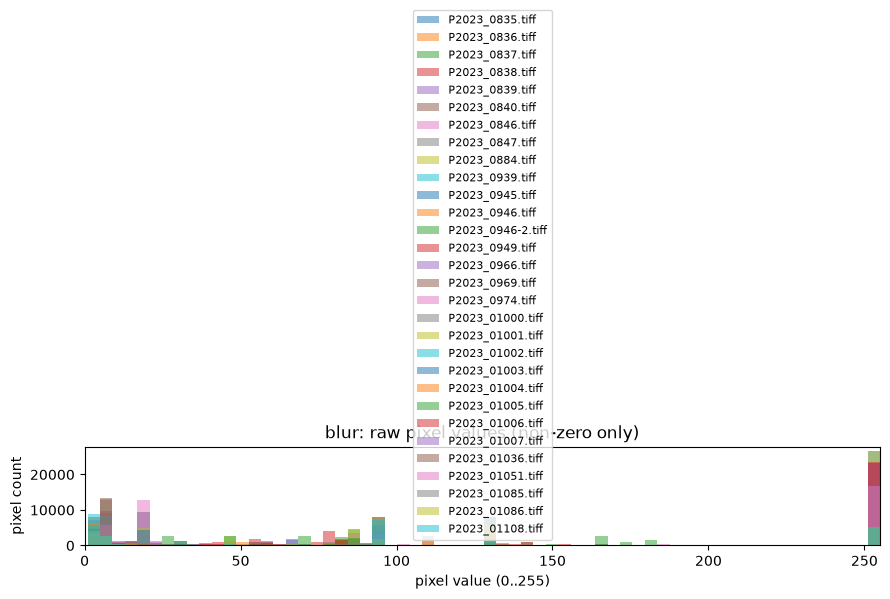


folding [P2023_0835.tiff]: ==0 100.0% | ==255   0.0% | 1..254   0.0% -> ~binary  (min 0, max 150)
folding [P2023_0836.tiff]: ==0 100.0% | ==255   0.0% | 1..254   0.0% -> ~binary  (min 0, max 150)
folding [P2023_0837.tiff]: ==0 100.0% | ==255   0.0% | 1..254   0.0% -> ~binary  (min 0, max 151)
folding [P2023_0838.tiff]: ==0 100.0% | ==255   0.0% | 1..254   0.0% -> ~binary  (min 0, max 150)
folding [P2023_0839.tiff]: ==0 100.0% | ==255   0.0% | 1..254   0.0% -> ~binary  (min 0, max 150)
folding [P2023_0840.tiff]: ==0 100.0% | ==255   0.0% | 1..254   0.0% -> ~binary  (min 0, max 225)
folding [P2023_0846.tiff]: ==0 100.0% | ==255   0.0% | 1..254   0.0% -> ~binary  (min 0, max 150)
folding [P2023_0847.tiff]: ==0 100.0% | ==255   0.0% | 1..254   0.0% -> ~binary  (min 0, max 150)
folding [P2023_0884.tiff]: ==0 100.0% | ==255   0.0% | 1..254   0.0% -> ~binary  (min 0, max 150)
folding [P2023_0939.tiff]: ==0 100.0% | ==255   0.0% | 1..254   0.0% -> ~binary  (min 0, max 206)
folding [P2023_0945

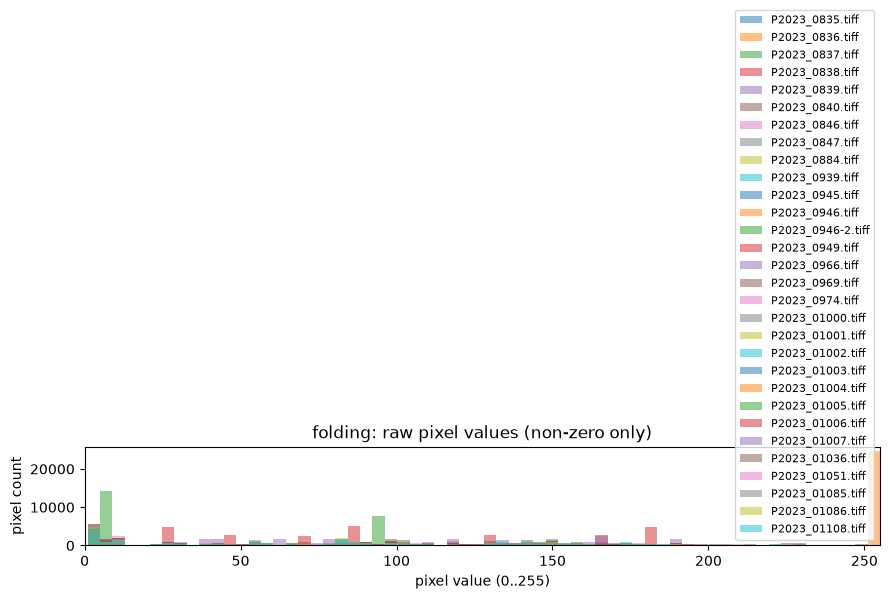


residual [P2023_0835.tiff]: ==0  35.1% | ==255  59.5% | 1..254   5.5% -> CONTINUOUS  (min 0, max 255)
residual [P2023_0836.tiff]: ==0  65.2% | ==255   0.7% | 1..254  34.1% -> CONTINUOUS  (min 0, max 255)
residual [P2023_0837.tiff]: ==0  64.9% | ==255   0.7% | 1..254  34.5% -> CONTINUOUS  (min 0, max 255)
residual [P2023_0838.tiff]: ==0  66.1% | ==255   0.4% | 1..254  33.5% -> CONTINUOUS  (min 0, max 255)
residual [P2023_0839.tiff]: ==0  73.7% | ==255   0.0% | 1..254  26.3% -> CONTINUOUS  (min 0, max 255)
residual [P2023_0840.tiff]: ==0  75.3% | ==255   0.0% | 1..254  24.7% -> CONTINUOUS  (min 0, max 209)
residual [P2023_0846.tiff]: ==0  75.1% | ==255   0.0% | 1..254  24.9% -> CONTINUOUS  (min 0, max 224)
residual [P2023_0847.tiff]: ==0  74.9% | ==255   0.0% | 1..254  25.1% -> CONTINUOUS  (min 0, max 236)
residual [P2023_0884.tiff]: ==0  75.3% | ==255   0.0% | 1..254  24.7% -> CONTINUOUS  (min 0, max 232)
residual [P2023_0939.tiff]: ==0  66.3% | ==255   0.0% | 1..254  33.7% -> CONTINUO

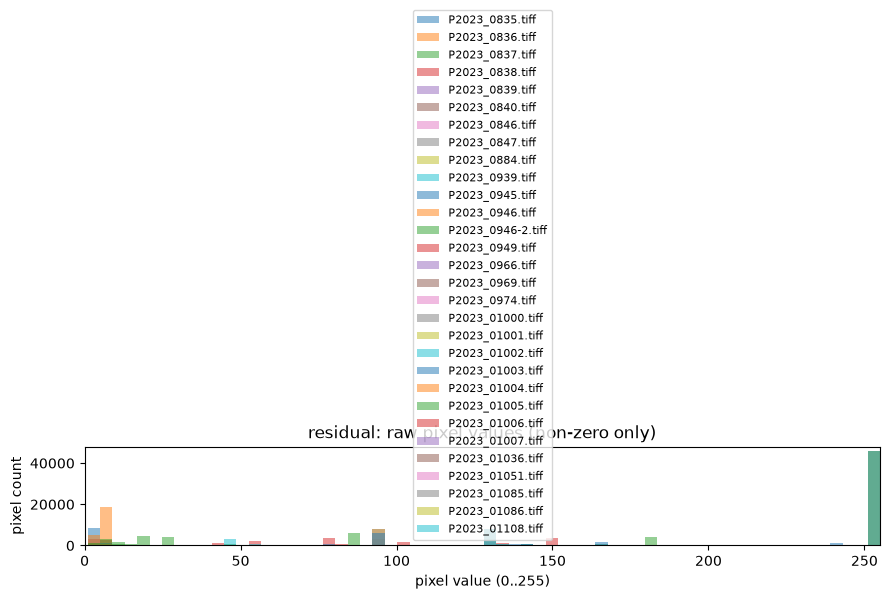


tissue [P2023_0835.tiff]: ==0  83.2% | ==255  12.1% | 1..254   4.7% -> CONTINUOUS  (min 0, max 255)
tissue [P2023_0836.tiff]: ==0  80.3% | ==255   9.6% | 1..254  10.1% -> CONTINUOUS  (min 0, max 255)
tissue [P2023_0837.tiff]: ==0  86.1% | ==255   6.1% | 1..254   7.7% -> CONTINUOUS  (min 0, max 255)
tissue [P2023_0838.tiff]: ==0  85.3% | ==255   6.1% | 1..254   8.6% -> CONTINUOUS  (min 0, max 255)
tissue [P2023_0839.tiff]: ==0  83.2% | ==255   8.2% | 1..254   8.6% -> CONTINUOUS  (min 0, max 255)
tissue [P2023_0840.tiff]: ==0  79.2% | ==255   7.6% | 1..254  13.1% -> CONTINUOUS  (min 0, max 255)
tissue [P2023_0846.tiff]: ==0  80.8% | ==255  10.5% | 1..254   8.7% -> CONTINUOUS  (min 0, max 255)
tissue [P2023_0847.tiff]: ==0  80.3% | ==255   8.7% | 1..254  11.0% -> CONTINUOUS  (min 0, max 255)
tissue [P2023_0884.tiff]: ==0  84.6% | ==255   7.0% | 1..254   8.4% -> CONTINUOUS  (min 0, max 255)
tissue [P2023_0939.tiff]: ==0  82.9% | ==255   7.6% | 1..254   9.5% -> CONTINUOUS  (min 0, max 255)

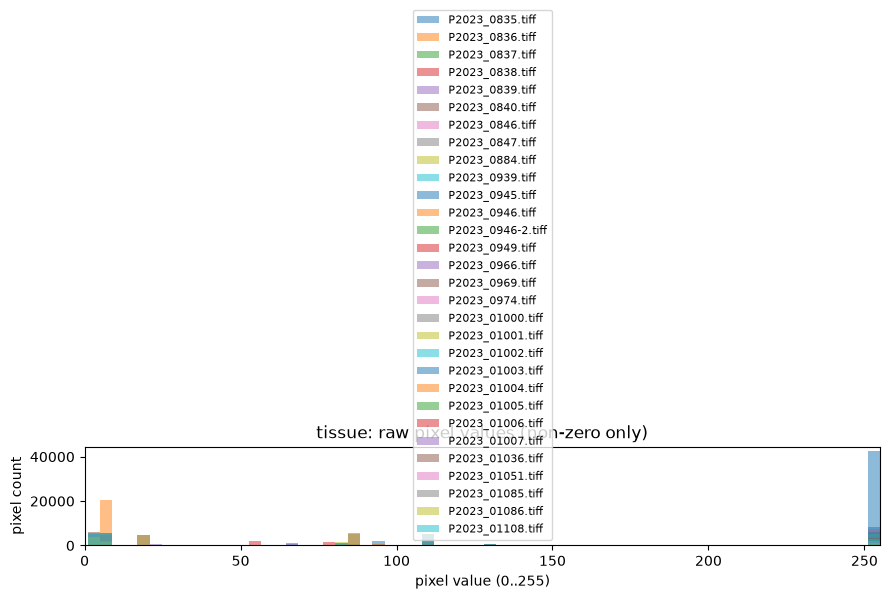

In [12]:
# Inspect raw mask pixel distributions. Read the printed "1..254" fraction per mask:
#   large  -> CONTINUOUS (equality-based overlap in tiling.py under-counts artifacts; needs fixing)
#   ~0%    -> effectively BINARY (equality is fine)
# Also compare shapes: is 0 = clean and non-zero = artifact (QC docs), and where does the mass sit?
inspect_raw_masks()